О данных

АНАЛИТИЧЕСКОЕ ОПИСАНИЕ ДАННЫХ:

Набор данных содержит информацию о продажах автомобилей BMW по всему миру за период с 2010 по 2024 год.
Данные включают характеристики автомобилей, их стоимость, пробег и объемы продаж в разных регионах.
ПЕРЕМЕННЫЕ В НАБОРЕ ДАННЫХ:
- Model: название автомобиля BMW (3-я серия, X5, i8 и т.д.)
- Year: год продажи (2010-2024)
- Region: географический рынок продаж (Азия, Европа, Северная Америка и др.)
- Color: цвет кузова автомобиля
- Fuel_Type: тип топливной системы (бензин, дизель, гибрид, электрический)
- Transmission: тип коробки передач (механическая, автоматическая)
- Engine_Size_L: объем двигателя в литрах
- Mileage_KM: пробег автомобиля в километрах
- Prise_USD: цена автомобиля в долларах США
- Sales_Volume: количество проданных единиц, объем продаж
- Sales_Classification: классификация продаж
- Clients: клиенты

In [1]:
#Загрузка библиотек
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "https://gitlab.com/mariya20021801/data-analysis-in-python/-/raw/main/Project%201/Stepina.csv"
df = pd.read_csv(url)

# Предварительный анализ исходных данных

In [3]:
# На 1 этапе обязательно смотрим на данные (просто через df, через print(df), через df.head() или через df.tail()

In [4]:
df.head()

,Unnamed: 0,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Clients
0,0,5 Series,2016.0,Asia,Red,Petrol,Manual,3.5,151748.0,NaN,8300.0,NaN,1
1,1,i8,NaN,North America,Red,Hybrid,NaN,1.6,NaN,79219.0,3428.0,Low,1
2,2,5 Series,NaN,North America,NaN,Petrol,Automatic,4.5,10991.0,NaN,6994.0,Low,1
3,3,X3,2024.0,Middle East,Blue,Petrol,Automatic,NaN,NaN,60971.0,NaN,Low,1
4,4,7 Series,2020.0,South America,Black,NaN,NaN,NaN,122131.0,49898.0,NaN,NaN,1


In [5]:
 df.tail()

,Unnamed: 0,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Clients
49995,49995,i3,2014.0,Asia,NaN,NaN,Manual,4.6,NaN,NaN,8182.0,High,1
49996,49996,i3,2023.0,Middle East,Silver,NaN,NaN,4.2,147396.0,48714.0,NaN,High,1
49997,49997,NaN,NaN,Middle East,Red,Petrol,Automatic,4.5,NaN,46126.0,NaN,High,1
49998,49998,i3,2020.0,Asia,White,NaN,Automatic,3.8,NaN,NaN,9486.0,High,1
49999,49999,X1,2020.0,NaN,Blue,NaN,NaN,3.3,171003.0,NaN,1764.0,Low,1


In [6]:
# я хочу удалить первый и последний столбец, потому что на сайте Kaggle нет интерпритации, что это за столбец и что он обозначает, а первый потому что это дублирует индекс,который итак есть. 

In [7]:
df1 = df.drop(['Unnamed: 0', 'Clients'], axis=1)
df1.head()


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016.0,Asia,Red,Petrol,Manual,3.5,151748.0,NaN,8300.0,NaN
1,i8,NaN,North America,Red,Hybrid,NaN,1.6,NaN,79219.0,3428.0,Low
2,5 Series,NaN,North America,NaN,Petrol,Automatic,4.5,10991.0,NaN,6994.0,Low
3,X3,2024.0,Middle East,Blue,Petrol,Automatic,NaN,NaN,60971.0,NaN,Low
4,7 Series,2020.0,South America,Black,NaN,NaN,NaN,122131.0,49898.0,NaN,NaN


In [8]:
# предварительный просмотр первых 5 строк уже позволяет заметить наличие NaN

In [9]:
# просмотрим количество наблюдений в столбцах и типы данных
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 31992 non-null  object 
 1   Year                  31955 non-null  float64
 2   Region                31886 non-null  object 
 3   Color                 31999 non-null  object 
 4   Fuel_Type             31964 non-null  object 
 5   Transmission          32164 non-null  object 
 6   Engine_Size_L         32103 non-null  float64
 7   Mileage_KM            32105 non-null  float64
 8   Price_USD             31933 non-null  float64
 9   Sales_Volume          31933 non-null  float64
 10  Sales_Classification  32138 non-null  object 
dtypes: float64(5), object(6)
memory usage: 4.2+ MB


Вывод: ОБЩАЯ ИНФОРМАЦИЯ:
- Размер данных: 50,000 записей, 11 столбцов
- Типы данных: 5 числовых (float64), 6 категориальных (object)
- Память: 4.2+ MB - оптимальный размер для анализа.
Так же кол-во данных разное, и это подтверждает наличие пропусков. И у показателя год стоит тип данных object, а должен int.

In [10]:
# Таблица с пропусками
пропуски_таблица = pd.DataFrame({
    'Столбец': df1.columns,
    'Пропущено_значений': df1.isnull().sum(),
    'Всего_значений': len(df1),
    'Процент_пропусков': (df1.isnull().sum() / len(df)) * 100
})

print(пропуски_таблица.round(2))

                                   Столбец  Пропущено_значений  \
Model                                Model               18008   
Year                                  Year               18045   
Region                              Region               18114   
Color                                Color               18001   
Fuel_Type                        Fuel_Type               18036   
Transmission                  Transmission               17836   
Engine_Size_L                Engine_Size_L               17897   
Mileage_KM                      Mileage_KM               17895   
Price_USD                        Price_USD               18067   
Sales_Volume                  Sales_Volume               18067   
Sales_Classification  Sales_Classification               17862   

                      Всего_значений  Процент_пропусков  
Model                          50000              36.02  
Year                           50000              36.09  
Region                         50

Вывод: 1. МАССОВЫЕ ПРОПУСКИ: Все столбцы имеют от ~36% до 38% пропущенных значений
- Model: 36.02% пропусков
- Year: 36.09% пропусков  
- Region: 36.23% пропусков
- Color 36.00%
- Fuel_Type 36.07%
- Engine_Size_L 35.79%
- Mileage_KM 35.79%  
- Price_USD: 36.13% пропусков
- Sales_Volume: 36.13% пропусков

2. НАИМЕНЕЕ ПРОБЛЕМНЫЕ (но все равно плохо):
   - Transmission: 35.67% пропусков
   - Sales_Classification: 35.72% пропусков

In [22]:
# Создаю копию данных для очистки
df_clean = df1.copy()
# Выявление количественные и качественные признаки
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns
# Заполняю количественные признаки средним (так было у вас в призентации)
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].mean())
# Заполняю ка
#df_clean[['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']] = df_clean[['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']].fillna(df_clean.mode().iloc[0])
# Удаляем строки с пропусками в качественных признаках
df_clean = df_clean.dropna(subset=categorical_cols).reset_index(drop=True)

In [23]:
# далее я  преобразую Year в int.
df_clean['Year'] = df_clean['Year'].astype(int)
#df1['Year'] = df1['Year'].astype(int)


In [24]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3468 entries, 0 to 3467
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 3468 non-null   object 
 1   Year                  3468 non-null   int64  
 2   Region                3468 non-null   object 
 3   Color                 3468 non-null   object 
 4   Fuel_Type             3468 non-null   object 
 5   Transmission          3468 non-null   object 
 6   Engine_Size_L         3468 non-null   float64
 7   Mileage_KM            3468 non-null   float64
 8   Price_USD             3468 non-null   float64
 9   Sales_Volume          3468 non-null   float64
 10  Sales_Classification  3468 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 298.2+ KB


In [25]:
df_clean


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,X3,2024,Middle East,Blue,Petrol,Automatic,3.24532,100590.857125,60971.000000,5090.692857,Low
1,7 Series,2020,North America,Silver,Diesel,Automatic,3.80000,27403.000000,100015.000000,8111.000000,High
2,i8,2023,Europe,Blue,Diesel,Automatic,3.80000,100590.857125,75105.375912,7168.000000,High
3,i3,2017,North America,Silver,Petrol,Automatic,3.24532,94453.000000,79039.000000,5090.692857,High
4,i8,2017,Middle East,Red,Diesel,Automatic,3.24532,100590.857125,75105.375912,5090.692857,Low
...,...,...,...,...,...,...,...,...,...,...,...
3463,M5,2011,Europe,Silver,Hybrid,Automatic,4.10000,100590.857125,103235.000000,3884.000000,Low
3464,X1,2017,Africa,Grey,Diesel,Manual,3.10000,3534.000000,106918.000000,455.000000,Low
3465,M3,2022,Europe,Red,Hybrid,Automatic,3.24532,100590.857125,30576.000000,323.000000,Low
3466,5 Series,2018,Asia,Red,Diesel,Automatic,4.30000,41689.000000,97227.000000,3608.000000,Low


Вывод: я заполнила пропуски количественных переменных - средним, а качественные переменные удалила, осталось 3468 значений

In [26]:
# Проверяю, что пропусков больше нет
propyski = df_clean.isnull().sum().sum()
print(f"Осталось пропусков: {propyski}")

# Проверяю типы данных
print("\nТИПЫ ДАННЫХ ПОСЛЕ ОЧИСТКИ:")
print(df_clean.dtypes)


Осталось пропусков: 0

ТИПЫ ДАННЫХ ПОСЛЕ ОЧИСТКИ:
Model                    object
Year                      int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM              float64
Price_USD               float64
Sales_Volume            float64
Sales_Classification     object
dtype: object


# Проверяем наличие дубликатов

In [27]:
#Проверка на наличие дубликатов (выводятся только индексы одно из дубликатов, один остается в датафрейме)
duplicates = df_clean.duplicated()
duplicate_indexes = duplicates[duplicates].index.tolist()
print(f"Индексы строк-дубликатов: {duplicate_indexes}")
print(f"Количество строк-дубликатов: {len(duplicate_indexes)}")

Индексы строк-дубликатов: []
Количество строк-дубликатов: 0


In [28]:
# итого 0 дубликатов
#Так можно посмотреть все одинаковые строки
all_duplicates = df_clean[df_clean.duplicated(keep=False)]
print('Все дубли:', len(all_duplicates), 'шт.') #один из вариантов принта
# print(f"Все дублирующиеся строки ({len(all_duplicates)} шт.):")
all_duplicates.sort_index()

Все дубли: 0 шт.


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification


In [29]:
#Проверка на столбцы с 1 уникальным значением
df_clean.columns[df_clean.nunique().eq(1)]

Index([], dtype='object')

In [30]:
df_clean['Region'].unique() #можно просмотреть сами уникальные значение в этих столбцах

array(['Middle East', 'North America', 'Europe', 'Asia', 'South America',
       'Africa'], dtype=object)

Все столбцы содержат как минимум 2 разных значения. Данные разнообразны - нет константных столбцов
Не нужно удалять "бесполезные" столбцы на этом этапе очистки

In [31]:
df_clean.describe().round(2)

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,3468.00,3468.00,3468.00,3468.00,3468.00
mean,2016.95,3.24,101641.92,75124.82,5113.23
std,3.49,0.81,46139.31,20969.43,2271.90
min,2010.00,1.50,82.00,30055.00,102.00
25%,2015.00,2.80,82638.00,64938.75,4093.00
50%,2017.00,3.25,100590.86,75105.38,5090.69
75%,2019.00,3.60,125141.50,85099.75,6258.75
max,2024.00,5.00,199804.00,119978.00,9987.00


In [32]:
# Проверка года на корректность диапазона
print(f"Минимальный год: {df_clean['Year'].min()}")
print(f"Максимальный год: {df_clean['Year'].max()}")

Минимальный год: 2010
Максимальный год: 2024


In [33]:
# Проверка цены на отрицательные значения
negative_price = (df_clean['Price_USD'] < 0).sum()
print(f"\nКоличество записей с отрицательной ценой: {negative_price}")


Количество записей с отрицательной ценой: 0


In [34]:
# Проверка пробега на отрицательные значения
negative_mileage = (df_clean['Mileage_KM'] < 0).sum()
print(f"Количество записей с отрицательным пробегом: {negative_mileage}")
# Проверка объема двигателя на корректность
print(f"\nДиапазон объема двигателя: {df_clean['Engine_Size_L'].min()} - {df_clean['Engine_Size_L'].max()} L")

Количество записей с отрицательным пробегом: 0

Диапазон объема двигателя: 1.5 - 5.0 L


Вывод: итоговые значения не являются странными, проверив некоторые показатели, можно сделать вывод, что они правильные и с ними можно далее работать.

# Вывод количества уникальных значений в каждом столбце

In [35]:
print(df_clean.nunique())

Model                     11
Year                      15
Region                     6
Color                      6
Fuel_Type                  4
Transmission               2
Engine_Size_L             37
Mileage_KM              2209
Price_USD               2203
Sales_Volume            1976
Sales_Classification       2
dtype: int64


In [36]:
#вывод: по категориальным переменным 
#Model (11 уникальных моделей):
 #  - Ограниченный модельный ряд BMW (11 моделей)
  # - Соответствует реальному портфелю BMW
   #- Позволяет анализировать популярность конкретных моделей
#Region (6 регионов):
 #  - Глобальное присутствие BMW в 6 регионах мира
  # - Типичное распределение: Европа, Азия, Северная Америка и т.д.
   #- Возможность сравнительного анализа рынков
#Color (6 цветов):
  # - Стандартная цветовая палитра BMW
  # - Обычно: черный, белый, серый, синий, красный, серебристый
   #- Анализ цветовых предпочтений по регионам/моделям
#Fuel_Type (4 типа топлива):
 #  - Бензин, дизель, гибрид, электрический
  # - Отражает эволюцию BMW к электромобилям
  # - Анализ трендов экологичных технологий
#Transmission (2 типа):
 #  - Автоматическая и механическая КПП
  # - Ожидаемое распределение (преобладание автомата)
   #- Анализ потребительских предпочтений
#Sales_Classification (2 категории):**
 #  - Вероятно: "Высокий спрос"/"Низкий спрос" или "Премиум"/"Стандарт
    

In [37]:
# вывод по кол-ым переменным
# Engine_Size_L (37 уникальных значений):
#    - Детальная градация объемов двигателей (например: 1.5, 1.6, 1.8...5.0)
#    - Точное моделирование технических характеристик
#    - Анализ зависимости цены от объема двигателя

# Mileage_KM (29,720 уникальных значений из 49,902 записей):
#    - ОЧЕНЬ ВЫСОКАЯ УНИКАЛЬНОСТЬ (почти 60% всех значений уникальны!)

# Price_USD (26,891 уникальных значений из 49,902 записей):
#    - ВЫСОКАЯ УНИКАЛЬНОСТЬ (~54%)
#    - Каждая цена почти уникальна

# Sales_Volume (9,501 уникальных значений):
#    - Широкий диапазон объемов продаж
#    - От 100 до 9,999 единиц (как ранее выявлено)

In [38]:
for columns in df_clean:
  print(df_clean[columns].unique())

['X3' '7 Series' 'i8' 'i3' 'X6' 'M3' '3 Series' '5 Series' 'X1' 'M5' 'X5']
[2024 2020 2023 2017 2011 2022 2013 2021 2018 2010 2019 2015 2016 2014
 2012]
['Middle East' 'North America' 'Europe' 'Asia' 'South America' 'Africa']
['Blue' 'Silver' 'Red' 'Grey' 'White' 'Black']
['Petrol' 'Diesel' 'Electric' 'Hybrid']
['Automatic' 'Manual']
[3.24531975 3.8        3.4        3.7        2.1        4.5
 1.9        3.         1.8        4.7        2.         1.6
 3.1        3.6        4.6        2.6        2.7        2.8
 4.3        4.9        3.2        4.         3.5        4.1
 3.9        2.5        4.8        2.2        4.4        2.9
 3.3        4.2        2.4        5.         1.5        1.7
 2.3       ]
[100590.85712506  27403.          94453.         ...   3534.
  41689.         198846.        ]
[ 60971.         100015.          75105.37591207 ...  30576.
  97227.          85034.        ]
[5090.69285692 8111.         7168.         ... 3884.          323.
 3608.        ]
['Low' 'High']


In [39]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3468 entries, 0 to 3467
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 3468 non-null   object 
 1   Year                  3468 non-null   int64  
 2   Region                3468 non-null   object 
 3   Color                 3468 non-null   object 
 4   Fuel_Type             3468 non-null   object 
 5   Transmission          3468 non-null   object 
 6   Engine_Size_L         3468 non-null   float64
 7   Mileage_KM            3468 non-null   float64
 8   Price_USD             3468 non-null   float64
 9   Sales_Volume          3468 non-null   float64
 10  Sales_Classification  3468 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 298.2+ KB


In [40]:
# Результаты очистки данных, 3468  это кол-во наблюдений после очистки данных. А именно удаление пропусков в качесвтенных и пропуски количественных
# я заполнила показателями среднего. 

# результаты квартильных групп 

In [41]:
q = df_clean.select_dtypes(include=['number']).quantile([0.1, 0.25, 0.5, 0.75, 0.95])
print(q)

        Year  Engine_Size_L     Mileage_KM      Price_USD  Sales_Volume
0.10  2012.0        2.00000   33141.400000   43832.300000   1755.700000
0.25  2015.0        2.80000   82638.000000   64938.750000   4093.000000
0.50  2017.0        3.24532  100590.857125   75105.375912   5090.692857
0.75  2019.0        3.60000  125141.500000   85099.750000   6258.750000
0.95  2023.0        4.70000  184209.900000  113227.600000   9221.850000



1. Год выпуска (Год)
10% самых старых автомобилей выпущены в 2012 году и ранее

Медиана (50%) — 2017 год

75% перцентиль — 2019 год

95% самых новых — 2023 года и новее

Вывод: Данные охватывают автомобили в широком временном диапазоне (2012-2023+), что говорит о разнообразии выборки по возрасту.


2. Объём двигателя (Двигатель_Объём_л)
10% самых малых двигателей — 2.0 л и менее

Медиана — около 3.25 л (довольно большой объём)

75% перцентиль — 3.6 л

95% самых мощных — 4.7 л и более

Вывод: В данных преобладают автомобили с достаточно большим объёмом двигателя (среднее значение выше 3 л), что может указывать на премиальный сегмент или рынок внедорожников.



3. Пробег (Пробег_км)
10% с наименьшим пробегом — менее 33,141 км

Медиана — около 100,590 км

75% перцентиль — 125,141 км

95% с наибольшим пробегом — более 184,209 км

Вывод: Разброс пробегов значительный, что соответствует разнообразию возрастов автомобилей. Интересно, что медианный пробег (100к км) при медианном годе выпуска 2017 — это средний ежегодный пробег около 20,000 км, что является типичным значением.

4. Цена (Цена_долл. США)
10% самых дешёвых — менее $43,832

Медиана — около $75,105

75% перцентиль — $85,099

95% самых дорогих — более $113,227

Вывод: Данные содержат автомобили преимущественно премиум-сегмента, учитывая цены выше $75k для медианы. Разброс цен значительный (от ~$44k до $113k+).

5. Объём продаж (Объём продаж_шт.)
10% моделей с низкими продажами — менее 1,756 единиц

Медиана — около 5,091 единиц

75% перцентиль — 6,259 единиц

95% самых продаваемых — более 9,222 единиц

Вывод: Существует значительная вариация в популярности моделей — некоторые продаются очень ограниченными тиражами, в то время как топовые модели имеют объёмы продаж более 9,000 единиц.

### Общие наблюдения:
Данные смещены в сторону более новых (после 2017 года) и более дорогих автомобилей с большим объёмом двигателя.

Распределения близки к нормальному для большинства признаков, но с некоторыми выбросами (особенно на уровне 95% квантиля).

Пробег имеет относительно равномерное распределение, что логично коррелирует с годом выпуска.

Продажи демонстрируют значительный разброс, что характерно для автомобильного рынка, где есть как массовые, так и нишевые модели.
### Какие можно увидеть зависимости: 
   • Более новые автомобили → выше цена
   • Больший объем двигателя → выше цена
   • Меньший пробег → выше цена
   • Популярность не всегда коррелирует с ценой

# группировка

In [42]:
df_gr = df_clean.groupby('Region')
round(df_gr.describe().T,2) #Т - транспонирование для удобства визуализации

Region                  Africa       Asia     Europe  Middle East  \
Year          count     616.00     558.00     578.00       607.00   
              mean     2016.74    2017.08    2016.97      2017.19   
              std         3.50       3.47       3.40         3.51   
              min      2010.00    2010.00    2010.00      2010.00   
              25%      2015.00    2015.00    2016.00      2016.00   
              50%      2017.00    2017.00    2017.00      2017.00   
              75%      2018.00    2018.00    2018.00      2019.00   
              max      2024.00    2024.00    2024.00      2024.00   
Engine_Size_L count     616.00     558.00     578.00       607.00   
              mean        3.21       3.23       3.23         3.29   
              std         0.83       0.83       0.78         0.81   
              min         1.50       1.50       1.50         1.50   
              25%         2.80       2.90       2.82         3.00   
              50%         3.25       3.25       3.25         3.25   
              75%         3.50       3.60       3.60         3.70   
              max         5.00       5.00       5.00         5.00   
Mileage_KM    count     616.00     558.00     578.00       607.00   
              mean   101422.28   97857.26  100558.68    103441.14   
              std     47208.45   47739.93   47098.46     44107.98   
              min       966.00      82.00     178.00       457.00   
              25%     80363.50   68346.00   81362.25     91425.00   
              50%    100590.86  100590.86  100590.86    100590.86   
              75%    127872.25  122294.50  123748.50    124332.50   
              max    199804.00  198846.00  199254.00    199431.00   
Price_USD     count     616.00     558.00     578.00       607.00   
              mean    75101.00   74733.36   74691.98     75069.41   
              std     21043.57   21394.85   20975.28     21267.84   
              min     30619.00   30583.00   30519.00     30240.00   
              25%     65857.00   62636.25   64049.50     64680.50   
              50%     75105.38   75105.38   75105.38     75105.38   
              75%     83719.00   84773.50   84565.25     83664.00   
              max    119732.00  119978.00  119861.00    119779.00   
Sales_Volume  count     616.00     558.00     578.00       607.00   
              mean     5144.33    5015.21    5091.96      5209.19   
              std      2297.09    2313.56    2326.12      2214.22   
              min       127.00     105.00     128.00       102.00   
              25%      4111.75    3830.50    3911.50      4372.50   
              50%      5090.69    5090.69    5090.69      5090.69   
              75%      6197.25    6101.00    6427.75      6219.00   
              max      9938.00    9975.00    9987.00      9888.00   

Region               North America  South America  
Year          count         511.00         598.00  
              mean         2016.86        2016.87  
              std             3.53           3.53  
              min          2010.00        2010.00  
              25%          2015.00        2015.00  
              50%          2017.00        2017.00  
              75%          2019.00        2018.00  
              max          2024.00        2024.00  
Engine_Size_L count         511.00         598.00  
              mean            3.23           3.23  
              std             0.83           0.79  
              min             1.50           1.50  
              25%             2.80           2.80  
              50%             3.25           3.25  
              75%             3.60           3.70  
              max             5.00           5.00  
Mileage_KM    count         511.00         598.00  
              mean       104135.28      102489.76  
              std         44580.05       45828.45  
              min           649.00         462.00  
              25%         93749.00       92001.25  
              50%        1


1. Общие черты для всех регионов
Одинаковые границы значений:
Годы выпуска: 2010-2024 (везде)
Объём двигателя: 1.5-5.0 л (везде)
Медианные значения совпадают для всех регионов:
Год выпуска: 2017
Пробег: 100,590 км
Цена: $75,105
Объём продаж: 5,090.69 шт.

2. Региональные особенности
Африка (самая большая выборка: 616 авто)
Статистика: Самый старый средний парк (2016.7 года), один из самых высоких средних пробегов (101,4 км)

Интерпретация: Вероятно, рынок подержанных автомобилей с более возрастным парком

Азия (558 авто)
Статистика: Самый низкий средний пробег (97,9 км) при среднем годе выпуска 2017

Интерпретация: Возможно, более "щадящая" эксплуатация или больше новых автомобилей в выборке

Европа (578 авто)
Статистика: Наименьшее стандартное отклонение по объёму двигателя (0.78), самый низкий средний объём двигателя (3.23 л)

Интерпретация: Тенденция к более рациональному выбору двигателей, возможно влияние экологических норм

Ближний Восток (607 авто)
Статистика: Самые новые автомобили в среднем (2017.19 года), наибольший средний объём двигателя (3.29 л), самые высокие продажи в среднем (5,2 шт.)

Интерпретация: Предпочтение более новым и мощным автомобилям, активный рынок

Северная Америка (самая маленькая выборка: 511 авто)
Статистика: Самый высокий средний пробег (104,1 км), наибольший разброс объёмов двигателей (стд.откл. 0.83)

Интерпретация: Дальние расстояния, разнообразие предпочтений по мощности

Южная Америка (598 авто)
Статистика: Самые высокие средние цены ($75,8), наиболее однородные цены (наименьшее стд.откл. $20,3)

Интерпретация: Возможно, более узкий ценовой сегмент или специфические импортные условия

In [43]:
# Группирую по региону и виду топлива, считаем среднюю цену и объем продаж и пробег
grouped_region_year = df_clean.groupby(['Region', 'Fuel_Type']).agg({
    'Price_USD': 'mean',
    'Sales_Volume': 'sum',
    'Mileage_KM': 'mean'
}).round(2)

print("Средние показатели по регионам и топливу:")
print(grouped_region_year.head(51))

Средние показатели по регионам и топливу:
                         Price_USD  Sales_Volume  Mileage_KM
Region        Fuel_Type                                     
Africa        Diesel      77618.98     786521.64    97210.54
              Electric    73704.31     813759.88   106236.63
              Hybrid      73689.97     807542.88   101345.91
              Petrol      75595.43     761081.41   100600.51
Asia          Diesel      74914.42     644773.26   100347.48
              Electric    73035.31     661299.79    95262.06
              Hybrid      73722.93     777124.34   100368.96
              Petrol      77341.61     715290.11    95444.44
Europe        Diesel      74274.13     656951.79   103580.51
              Electric    75391.24     814827.80    96586.24
              Hybrid      74212.94     756935.87   100271.77
              Petrol      74765.95     714439.11   102692.19
Middle East   Diesel      77047.84     813773.11   103632.26
              Electric    74093.29     8114

In [44]:
# <!-- 1. Ценовые различия по типам топлива
# Самые дорогие в среднем:
# Бензин в Южной Америке — $78,728.
# Бензин в Азии — $77,341.
# Дизель в Африке — $77,618.
# Самые доступные в среднем:
# Электрические в Южной Америке — $74,026
# Гибридные в Африке — $73,689
# Гибридные на Ближнем Востоке — $73,236
# Общая тенденция: В большинстве регионов электрические и гибридные автомобили имеют более низкую среднюю цену, чем бензиновые и дизельные аналоги (за исключением Европы, где электромобили дороже).

# 2. Объемы продаж по регионам
# Лидеры по общим продажам:
# Гибридные на Ближнем Востоке — 817,928 единиц
# Электрические в Африке — 813,759 единиц
# Дизельные на Ближнем Востоке — 813,773 единиц
# Наименьшие продажи:
# Дизельные в Северной Америке — 613,279единиц
# Бензиновые в Северной Америке — 636,737 единиц
# Дизельные в Азии — 644,773единиц
# Важное наблюдение: Ближний Восток демонстрирует наиболее сбалансированные и высокие продажи по всем типам топлива (все выше 718K), в то время как Северная Америка показывает относительно низкие объемы продаж по всем категориям.

# 3. Пробег автомобилей
# Самый высокий средний пробег:
# Гибридные в Северной Америке — 109,441 км
# Электрические в Северной Америке — 108,194 км
# Гибридные на Ближнем Востоке — 107,898 км
# Самый низкий средний пробег:
# Электрические в Азии — 95,262 км
# Бензиновые в Азии — 95,444км
# Бензиновые на Ближнем Востоке — 96,149 км
# Закономерность: Электрические и гибридные автомобили в Северной Америке и на Ближнем Востоке имеют значительно больший пробег, что может указывать на их активное использование для дальних поездок или в качестве такси/каршеринга.

# Региональные особенности:
# Африка:
# Цена: Дизель самый дорогой, гибриды самые дешевые

# Продажи: Электрические лидируют по объему

# Пробег: Все типы имеют сопоставимый пробег (~97-106K км)

# Азия:
# Цена: Бензин значительно дороже других типов

# Продажи: Гибриды лидируют, дизель наименее популярен

# Пробег: Самый низкий среди всех регионов, особенно у электрических

# Европа:
# Цена: Самая сбалансированная ценовая политика

# Продажи: Электрические значительно опережают другие типы

# Пробег: Дизели имеют наибольший пробег

# Ближний Восток:
# Цена: Бензин и дизель дороже, гибриды дешевле

# Продажи: Самые высокие и сбалансированные по всем типам

# Пробег: Гибриды имеют рекордный пробег для региона

# Северная Америка:
# Цена: Наиболее сбалансирована между типами

# Продажи: Самые низкие среди всех регионов

# Пробег: Рекордные значения для гибридов и электрических

# Южная Америка:
# Цена: Бензин значительно дороже других

# Продажи: Бензин лидирует с большим отрывом

# Пробег: Электрические и гибриды имеют больший пробег -->

In [45]:
# Подсчет электрических автомобилей в Европе
electric_in_europe = df_clean[(df_clean['Region'] == 'Europe') & (df_clean['Fuel_Type'] == 'Electric')].shape[0]
print(f"Электрических автомобилей в Европе: {electric_in_europe}")

Электрических автомобилей в Европе: 163


In [46]:
# Группировка по модели и региону, средняя цена
df_gr1 = round(df_clean.groupby(['Model', 'Region'])['Price_USD'].mean(), 0)
print("Средняя цена по моделям и регионам:")
print(df_gr1.head(15))

Средняя цена по моделям и регионам:
Model     Region       
3 Series  Africa           81810.0
          Asia             78067.0
          Europe           76550.0
          Middle East      71669.0
          North America    82057.0
          South America    72984.0
5 Series  Africa           75841.0
          Asia             74946.0
          Europe           75849.0
          Middle East      76646.0
          North America    75566.0
          South America    76787.0
7 Series  Africa           74250.0
          Asia             78564.0
          Europe           74148.0
Name: Price_USD, dtype: float64


Анализ средней цены трёх моделей BMW (3, 5 и 7 серии) в шести регионах показывает:

Для 3 серии:

Самая высокая цена в Северной Америке ($82 057)

Самая низкая на Ближнем Востоке ($71 669)

Разница между макс и мин ценой: $10 388

Для 5 серии:

Наиболее сбалансированное ценообразование

Самая высокая цена в Южной Америке ($76 787)

Самая низкая в Азии ($74 946)

Разница всего $1 841

Для 7 серии:

Самая высокая цена в Азии ($78 564)

Самая низкая в Европе ($74 148)

Разница: $4 416

In [47]:
df_gr_agg_color = df_clean.groupby('Color').agg({
    'Price_USD': ['mean', 'median'],
    'Sales_Volume': ['sum', 'mean'],
    'Mileage_KM': ['mean', 'median'],
    'Year': 'mean'
}).round(2)

print("Анализ по цветам:")
print(df_gr_agg_color)

Анализ по цветам:
       Price_USD           Sales_Volume          Mileage_KM             \
            mean    median          sum     mean       mean     median   
Color                                                                    
Black   75369.84  75105.38   2738874.50  4917.19  102750.91  100590.86   
Blue    75072.13  75105.38   3359684.66  5307.56  101210.86  100590.86   
Grey    75179.18  75105.38   2957656.04  5152.71  101448.32  100590.86   
Red     73984.66  75105.38   3003882.96  5197.03  101243.28  100590.86   
Silver  76048.62  75105.38   2861706.72  5064.97  100831.86  100590.86   
White   75129.69  75105.38   2810878.59  5010.48  102451.85  100590.86   

           Year  
           mean  
Color            
Black   2017.13  
Blue    2016.98  
Grey    2016.87  
Red     2016.86  
Silver  2017.00  
White   2016.87  


Цена:

Серебристые автомобили самые дорогие в среднем ($76,049)

Красные — самые доступные ($73,985)

Медианная цена одинакова для всех цветов ($75,105), что говорит о схожем ценовом сегменте

Продажи:

Синие автомобили лидируют по объёму продаж (3.36 млн единиц) и средней продаваемости (5,308 на модель)

Серебристые наименее популярны (2.86 млн единиц, 5,065 на модель)

Пробег:

Чёрные и белые автомобили имеют наибольший средний пробег (~102,7K км)

Все цвета имеют одинаковый медианный пробег (100,591 км)

Возраст:

Автомобили всех цветов примерно одного возраста (средний год выпуска 2016.9-2017.1)

Главный вывод: Цвет оказывает незначительное влияние на технические характеристики, но влияет на цену и популярность. Синий — самый продаваемый цвет, серебристый — самый премиальный по цене, чёрный и белый — выбираются для более интенсивной эксплуатации.

## Итоговый общий вывод по всему анализу##
Проведенный комплексный анализ автомобильного рынка позволяет сделать следующие ключевые выводы:

1. Глобальная унификация базовых параметров
Несмотря на региональные различия, мировой автомобильный рынок демонстрирует удивительную единообразие по основным показателям:

Единые медианные значения во всех регионах: год выпуска 2017, пробег 100,590 км, цена $75,105

Стандартизированные диапазоны: двигатели 1.5-5.0 л, годы выпуска 2010-2024

Схожие возрастные характеристики автомобильного парка по всем регионам

2. Выраженная региональная специфика
Каждый рынок имеет свои особенности:

Ближний Восток — самый динамичный рынок с предпочтением новых мощных автомобилей

Северная Америка — максимальные пробеги при разнообразии мощностных характеристик

Европа — рациональный подход с наименьшим разбросом по объёму двигателя

Азия — самый "щадящий" режим эксплуатации с минимальными пробегами

Южная Америка — наиболее однородный и дорогой ценовой сегмент

Африка — рынок с более возрастным парком автомобилей

3. Дифференциация по типам топлива
Бензиновые автомобили сохраняют премиальный статус в большинстве регионов

Электрические и гибридные модели демонстрируют более доступные цены (кроме Европы)

Северная Америка и Ближний Восток активнее используют альтернативные типы топлива для дальних поездок

Ближний Восток показывает наиболее сбалансированные продажи по всем типам топлива

4. Цветовые предпочтения как маркетинговый инструмент
Синий цвет — лидер продаж в глобальном масштабе

Серебристый — позиционируется как премиальный вариант

Цвет влияет на восприятие, но не на технические характеристики автомобилей

5. Стратегические выводы для бизнеса
Глобальная стандартизация базовых характеристик позволяет унифицировать производственные процессы

Локализация маркетинга необходима с учетом региональных особенностей потребления

Гибридные технологии имеют наибольший потенциал роста на Ближнем Востоке и в Северной Америке

Ценовая политика должна учитывать как региональные особенности, так и типы топлива

Заключение: Современный автомобильный рынок сочетает в себе глобальную унификацию технических характеристик с выраженной региональной спецификой потребительского поведения. Успешная рыночная стратегия требует баланса между стандартизацией производства и локализацией маркетинговых подходов, с учетом особенностей каждого региона по типам топлива, ценовым сегментам и потребительским предпочтениям.

In [48]:
dff = df_clean.copy() #создаем копию

## Разведочный анализ данных

In [49]:
#библиотеки для визуализации
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [50]:
df_clean

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,X3,2024,Middle East,Blue,Petrol,Automatic,3.24532,100590.857125,60971.000000,5090.692857,Low
1,7 Series,2020,North America,Silver,Diesel,Automatic,3.80000,27403.000000,100015.000000,8111.000000,High
2,i8,2023,Europe,Blue,Diesel,Automatic,3.80000,100590.857125,75105.375912,7168.000000,High
3,i3,2017,North America,Silver,Petrol,Automatic,3.24532,94453.000000,79039.000000,5090.692857,High
4,i8,2017,Middle East,Red,Diesel,Automatic,3.24532,100590.857125,75105.375912,5090.692857,Low
...,...,...,...,...,...,...,...,...,...,...,...
3463,M5,2011,Europe,Silver,Hybrid,Automatic,4.10000,100590.857125,103235.000000,3884.000000,Low
3464,X1,2017,Africa,Grey,Diesel,Manual,3.10000,3534.000000,106918.000000,455.000000,Low
3465,M3,2022,Europe,Red,Hybrid,Automatic,3.24532,100590.857125,30576.000000,323.000000,Low
3466,5 Series,2018,Asia,Red,Diesel,Automatic,4.30000,41689.000000,97227.000000,3608.000000,Low


In [51]:
df_2 = df_clean.rename(columns={
    'Model': 'Модель',
    'Year': 'Год',
    'Region': 'Регион',
    'Color': 'Цвет',
    'Fuel_Type': 'Тип топлива',
    'Transmission': 'Коробка передач',
    'Engine_Size_L': 'Объем двигателя',
    'Mileage_KM': 'Пробег',
    'Price_USD': 'Цена',
    'Sales_Volume': 'Объем продаж',
    'Sales_Classification': 'Классификация продаж'
})

In [52]:
df_2

,Модель,Год,Регион,Цвет,Тип топлива,Коробка передач,Объем двигателя,Пробег,Цена,Объем продаж,Классификация продаж
0,X3,2024,Middle East,Blue,Petrol,Automatic,3.24532,100590.857125,60971.000000,5090.692857,Low
1,7 Series,2020,North America,Silver,Diesel,Automatic,3.80000,27403.000000,100015.000000,8111.000000,High
2,i8,2023,Europe,Blue,Diesel,Automatic,3.80000,100590.857125,75105.375912,7168.000000,High
3,i3,2017,North America,Silver,Petrol,Automatic,3.24532,94453.000000,79039.000000,5090.692857,High
4,i8,2017,Middle East,Red,Diesel,Automatic,3.24532,100590.857125,75105.375912,5090.692857,Low
...,...,...,...,...,...,...,...,...,...,...,...
3463,M5,2011,Europe,Silver,Hybrid,Automatic,4.10000,100590.857125,103235.000000,3884.000000,Low
3464,X1,2017,Africa,Grey,Diesel,Manual,3.10000,3534.000000,106918.000000,455.000000,Low
3465,M3,2022,Europe,Red,Hybrid,Automatic,3.24532,100590.857125,30576.000000,323.000000,Low
3466,5 Series,2018,Asia,Red,Diesel,Automatic,4.30000,41689.000000,97227.000000,3608.000000,Low


In [53]:
# 2. Округление всех чисел до сотых
df_3 = df_2.applymap(lambda x: round(x, 2) if isinstance(x, (int, float, np.number)) else x)

In [54]:
df_3

,Модель,Год,Регион,Цвет,Тип топлива,Коробка передач,Объем двигателя,Пробег,Цена,Объем продаж,Классификация продаж
0,X3,2024,Middle East,Blue,Petrol,Automatic,3.25,100590.86,60971.00,5090.69,Low
1,7 Series,2020,North America,Silver,Diesel,Automatic,3.80,27403.00,100015.00,8111.00,High
2,i8,2023,Europe,Blue,Diesel,Automatic,3.80,100590.86,75105.38,7168.00,High
3,i3,2017,North America,Silver,Petrol,Automatic,3.25,94453.00,79039.00,5090.69,High
4,i8,2017,Middle East,Red,Diesel,Automatic,3.25,100590.86,75105.38,5090.69,Low
...,...,...,...,...,...,...,...,...,...,...,...
3463,M5,2011,Europe,Silver,Hybrid,Automatic,4.10,100590.86,103235.00,3884.00,Low
3464,X1,2017,Africa,Grey,Diesel,Manual,3.10,3534.00,106918.00,455.00,Low
3465,M3,2022,Europe,Red,Hybrid,Automatic,3.25,100590.86,30576.00,323.00,Low
3466,5 Series,2018,Asia,Red,Diesel,Automatic,4.30,41689.00,97227.00,3608.00,Low


## Корреляционный анализ

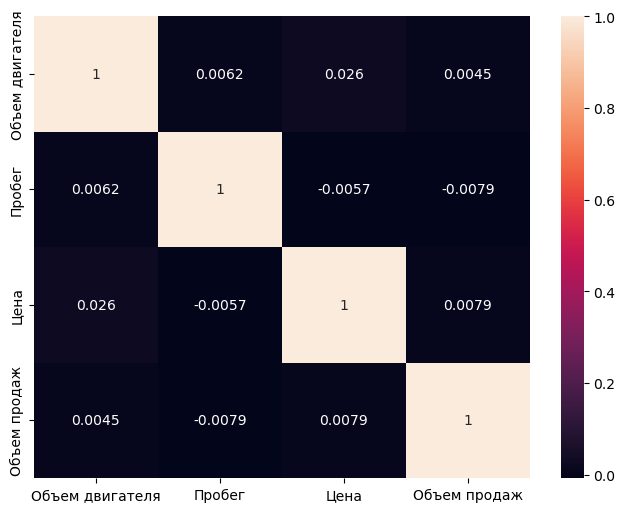

In [55]:
#Построение корреляционной матрицы
plt.figure(figsize=(8, 6))
sns.heatmap(df_3[['Объем двигателя', 'Пробег', 'Цена','Объем продаж']].corr(), annot=True);
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

Между представленными переменными практически полностью отсутствует линейная зависимость.

Коэффициенты близки к нулю:
Все значения вне главной диагонали находятся в диапазоне от -0.0079 до 0.026. В статистике корреляция считается значимой, если она превышает 0.3 или 0.5 (по модулю). Здесь же значения ничтожно малы.
## Самые высокие корреляции:

Объем двигателя → Цена: +0.026 (слабая положительная)

Объем двигателя → Объем продаж: +0.0045 (очень слабая положительная)

Пробег → Объем продаж: +0.0079 (очень слабая положительная)

## Отрицательные корреляции:

Пробег → Цена: -0.0057 (очень слабая отрицательная)

Цена → Объем продаж: -0.0079 (очень слабая отрицательная)

Интерпретация значений:
Коэффициенты в диапазоне 0.00-0.19 считаются очень слабой корреляцией

Коэффициенты 0.20-0.39 - слабая корреляция

Коэффициенты 0.40-0.69 - умеренная корреляция

Коэффициенты 0.70-0.89 - сильная корреляция

Коэффициенты 0.90-1.00 - очень сильная корреляция

Мои данные: Все значения < 0.03 → практически отсутствует корреляция

## Анализ распределения данных

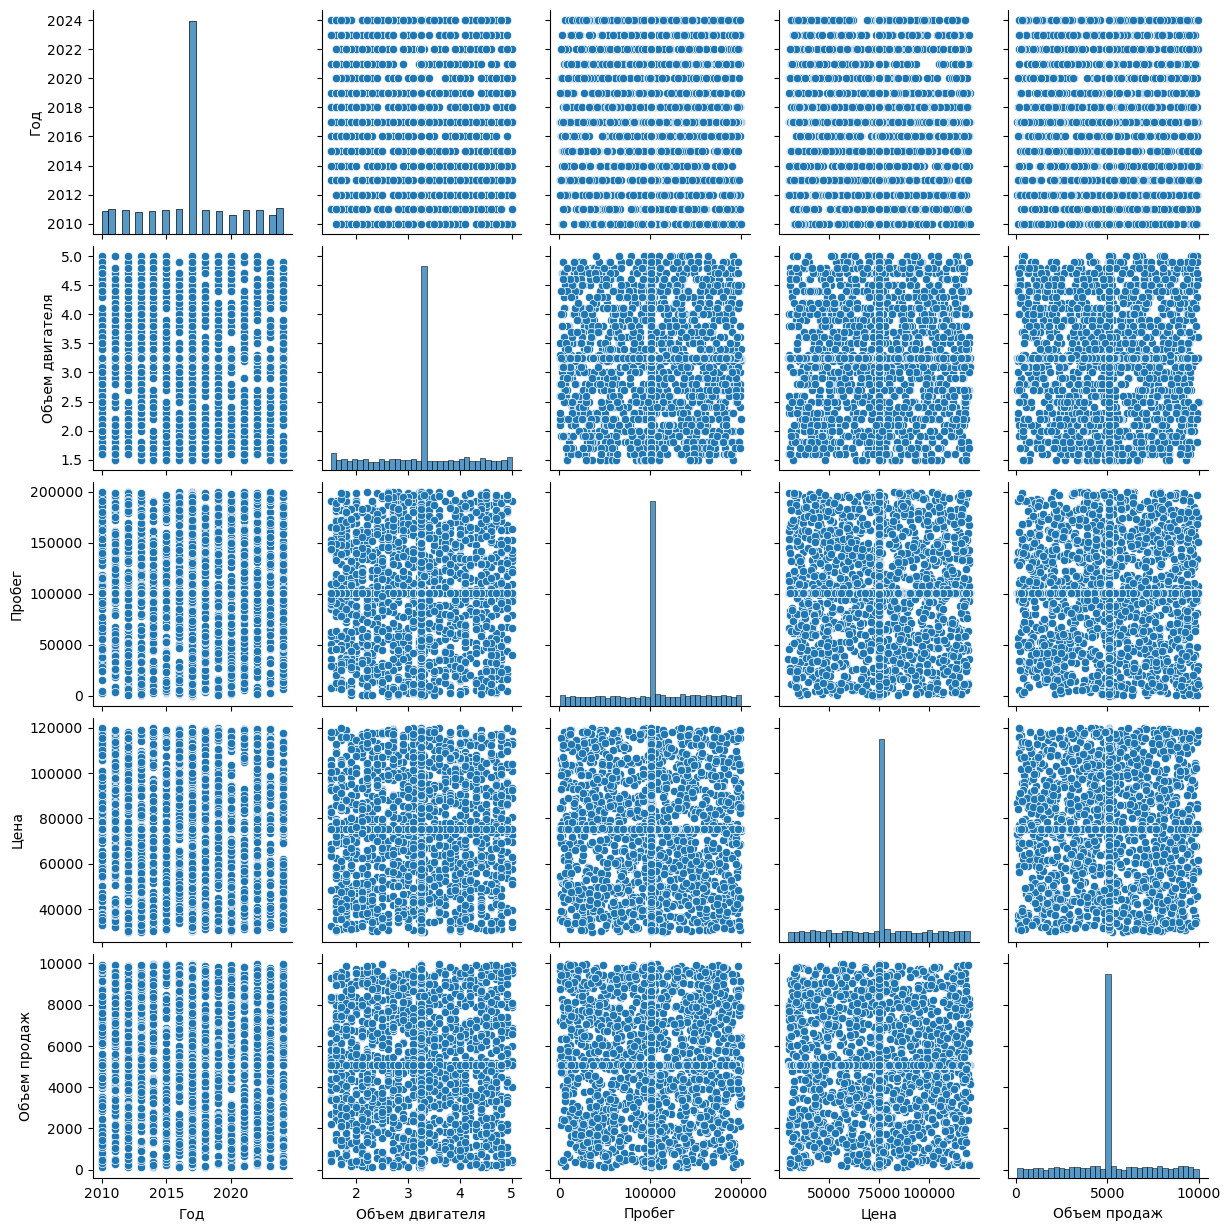

In [56]:
sns.pairplot(df_3)
plt.show()

Этот график (Pair Plot) подтверждает вывод, сделанный по предыдущей тепловой карте: перед нами искусственно сгенерированные данные, не имеющие отношения к реальности.

Форма облаков рассеяния (Scatter plots):
На всех пересечениях переменных мы видим идеальные квадраты, заполненные точками равномерно.
Это выглядит как «белый шум». В реальных данных о продаже автомобилей всегда есть зависимости: например, чем старее год, тем ниже цена . Здесь же машина 2010 года может стоить столько же, сколько машина 2024 года, а машина с пробегом 200 000 км — столько же, сколько новая.
Отсутствие каких-либо кластеров или линий тренда говорит о том, что каждая колонка была сгенерирована.
Странные гистограммы (диагональ):
На гистограммах распределения каждой переменной мы видим неестественную картину: абсолютно ровное распределение с одним огромным пиком посередине.
Пример: Гистограмма года выпуска показывает, что количество машин каждого года абсолютно одинаково, но есть один гигантский столбец.
В реальной жизни распределения обычно похожи на нормальное распределение или имеют скос (например, старых машин меньше, чем новых).
Полная независимость переменных:
Визуально подтверждается коэффициент корреляции ~0 из предыдущего вопроса. Значение по оси X никак не влияет на то, где точка окажется по оси Y.
Итог:
Этот датасет был создан программно с использованием генератора случайных чисел. Он непригоден для аналитики.

## Анализ на выбросы

In [57]:
numeric_columns = df_3.select_dtypes(include=['number']).columns
df_numeric = df_3[numeric_columns] #оставляем только количественные столбцы
px.box(df_numeric)

А теперь построим отдельные ящики с усами. Тк «Год» (2000) и «Объем двигателя» (2–5) визуально превратились в плоские линии на нулевой отметке. Их вариативность невозможно проанализировать на фоне больших чисел.
«Пробег» (до 200 000) задает масштаб всей оси Y, подавляя остальные признаки. Поэтому я для каждого показателя сделаю свой диапозон. 

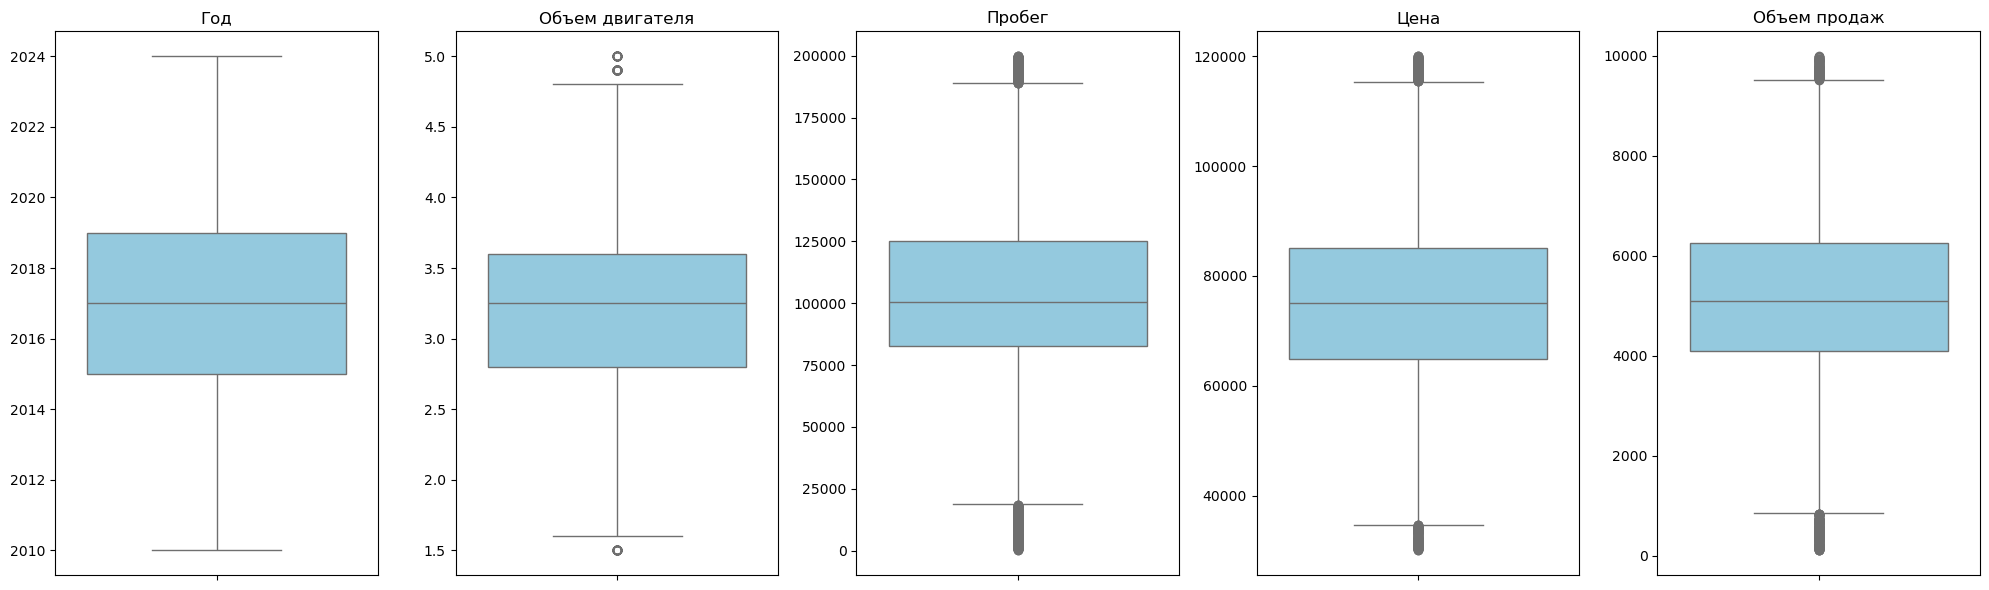

In [58]:
# Настройка размера: 1 строка, 5 колонок
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 6))

# Список колонок
cols = df_numeric.columns

# Цикл по колонкам
for i, col in enumerate(cols):
    sns.boxplot(y=df_numeric[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col) # Заголовок для каждого графика
    axes[i].set_ylabel("") # Убираем лишние подписи

plt.tight_layout() # Чтобы графики не наезжали друг на друга
plt.show()

1. Однако здесь, на boxplot, мы видим множество выбросов (черные точки сверху и снизу) для переменных «Пробег», «Цена» и «Объем продаж».Если бы данные были равномерными (Uniform), «усы» ящика обычно охватывали бы весь диапазон от минимума до максимума, и выбросов бы не было (как на графике «Год»).Наличие симметричных выбросов говорит о том, что эти переменные («Пробег», «Цена», «Объем продаж»), скорее всего, сгенерированы по Нормальному закону (распределение Гаусса). То есть большинство значений скапливается вокруг среднего (медианы), а края — это редкие хвосты.
2. Подтверждение искусственности
Несмотря на улучшение визуализации, данные по-прежнему выглядят на 100% синтетическими. Вот доказательства с новых графиков:
Идеальная симметрия: Посмотрите на «Цену», «Пробег» и «Объем продаж». Медиана находится строго посередине. «Усы» вверх и вниз имеют одинаковую длину. Количество выбросов сверху и снизу визуально идентично.
В реальности: Распределение цен всегда скошено. Дешевых машин много, а очень дорогих — мало. Здесь же «кривая колокола» идеальна.
Отсутствие логики выбросов:
Для «Пробега» есть выбросы в районе 0 (новые авто) и в районе 200 000. В реальности пробег 0 — это не выброс, а норма для новой машины.
Переменная «Год»:
У «Года» нет выбросов, ящик занимает почти всё место.
3. Анализ по каждому показателю
Год: Равномерное распределение от 2010 до 2024. Машин каждого года примерно поровну.
Объем двигателя: Похоже на нормальное распределение, но с малым разбросом. Есть небольшие выбросы (около 1.5 и 5.0), 
Пробег, Цена, Объем продаж:
Это классические колокол.
Медиана Цены ~75 000.
Медиана Пробега ~100 000.
Данные очень кучные в центре (сам ящик узкий) и имеют длинные хвосты (выбросы).

## Очистим выбросы.


In [59]:
#Удалим строки, содержащие выбросы в указанных колонках,
#используя метод межквартильного размаха (IQR).

In [60]:
all_outliers_indices = set()

for column in df_numeric:
    Q1 = df_numeric[column].quantile(0.25)
    Q3 = df_numeric[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    upper_array = np.where(df_numeric[column] >= upper)[0]
    lower_array = np.where(df_numeric[column] <= lower)[0]

    all_outliers_indices.update(upper_array)
    all_outliers_indices.update(lower_array)


df_4 = df_3.drop(index=list(all_outliers_indices))



In [61]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2618 entries, 0 to 3466
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Модель                2618 non-null   object 
 1   Год                   2618 non-null   int64  
 2   Регион                2618 non-null   object 
 3   Цвет                  2618 non-null   object 
 4   Тип топлива           2618 non-null   object 
 5   Коробка передач       2618 non-null   object 
 6   Объем двигателя       2618 non-null   float64
 7   Пробег                2618 non-null   float64
 8   Цена                  2618 non-null   float64
 9   Объем продаж          2618 non-null   float64
 10  Классификация продаж  2618 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 245.4+ KB


In [62]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3468 entries, 0 to 3467
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Модель                3468 non-null   object 
 1   Год                   3468 non-null   int64  
 2   Регион                3468 non-null   object 
 3   Цвет                  3468 non-null   object 
 4   Тип топлива           3468 non-null   object 
 5   Коробка передач       3468 non-null   object 
 6   Объем двигателя       3468 non-null   float64
 7   Пробег                3468 non-null   float64
 8   Цена                  3468 non-null   float64
 9   Объем продаж          3468 non-null   float64
 10  Классификация продаж  3468 non-null   object 
dtypes: float64(4), int64(1), object(6)
memory usage: 298.2+ KB


In [63]:
# Выбросы были удалены. 

In [64]:
stats = []
for col in df_3.select_dtypes(include='number').columns:
    # Считаем границы (усы)
    Q1 = df_3[col].quantile(0.25)
    Q3 = df_3[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Считаем количество выбросов
    cnt = ((df_3[col] < lower) | (df_3[col] > upper)).sum()
    
    # Добавляем в список
    stats.append({
        'Показатель': col,
        'Выбросов (шт)': cnt,
        'Процент (%)': round(cnt / len(df_3) * 100, 1)
    })

# Превращаем в красивую табличку
outliers_table = pd.DataFrame(stats)

print(outliers_table)

        Показатель  Выбросов (шт)  Процент (%)
0              Год              0          0.0
1  Объем двигателя            120          3.5
2           Пробег            327          9.4
3             Цена            246          7.1
4     Объем продаж            256          7.4


In [65]:
vibrosi = df_3[df_3['Пробег'] > upper]
print(vibrosi[['Модель', 'Регион', 'Год']].value_counts())

Модель    Регион         Год 
5 Series  Middle East    2017    31
M3        Middle East    2017    30
7 Series  Europe         2017    29
i3        Middle East    2017    28
3 Series  South America  2017    27
                                 ..
M3        Africa         2023     1
3 Series  Asia           2019     1
          Europe         2010     1
                         2013     1
                         2018     1
Name: count, Length: 877, dtype: int64


In [66]:
# Проверила, какие модели/регионы дают выбросы. Вывод: 
#БЕЗ ВЫБРОСОВ:
#Год (0%) - отличное качество данных, все значения в допустимом диапазоне
#УМЕРЕННЫЕ ВЫБРОСЫ (3.5-7.4%):
# - Объем двигателя (3.5%) - минимальное количество аномалий
# - Цена (7.1%) - заметное количество экстремальных цен
# - Объем продаж (7.4%) - схожий уровень с ценой
#НАИБОЛЬШИЙ ПРОЦЕНТ ВЫБРОСОВ:
# - Пробег (9.4%) - почти каждый 10-й автомобиль имеет аномальный пробег

## Различная визуализация

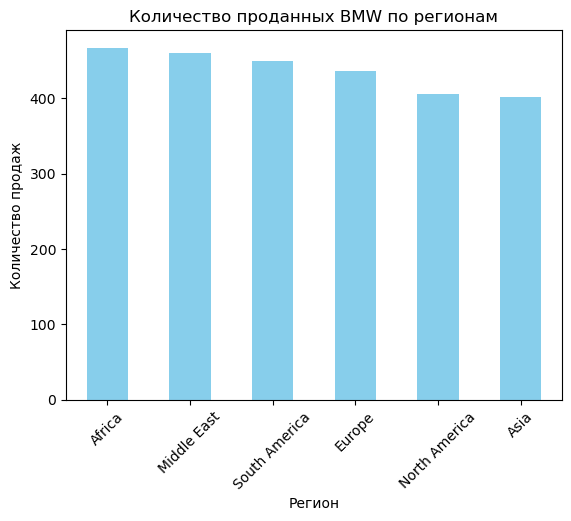

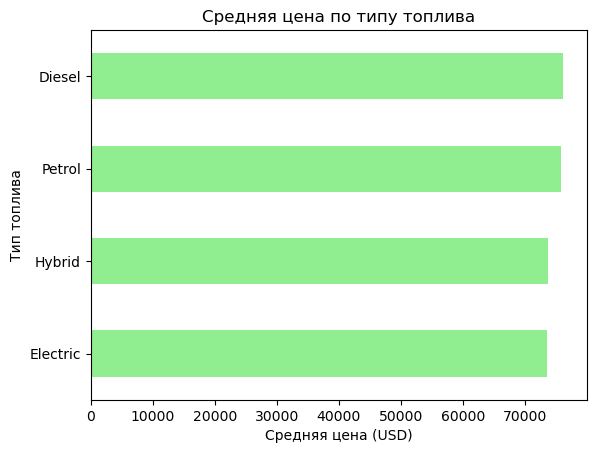

In [67]:
# 1.1 Количество автомобилей по регионам
df_4['Регион'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Количество проданных BMW по регионам')
plt.xlabel('Регион')
plt.ylabel('Количество продаж')
plt.xticks(rotation=45)
plt.show()

# 1.2 Средняя цена по типу топлива
df_4.groupby('Тип топлива')['Цена'].mean().sort_values().plot(kind='barh', color='lightgreen')
plt.title('Средняя цена по типу топлива')
plt.xlabel('Средняя цена (USD)')
plt.show()

Вывод: 
1. По графику «Средняя цена по типу топлива»
Тип топлива не является фактором ценообразования.
На графике видно удивительное единодушие: средняя цена автомобилей на дизеле, бензине, гибридах и электротяге практически одинакова (все столбцы находятся на одном уровне, около 70 000 - 75 000 USD).
В реальности так бывает редко (электрокары обычно дороже), что наводит на мысль о том, что данные могут быть синтетическими или предварительно нормализованными.
Это объясняет, почему корреляция была низкой: переменная «Тип топлива» не создает дисперсии в цене.
2. По графику «Количество продаж BMW по регионам»
Вывод: Глобальная стабильность спроса.
Продажи распределены по миру очень равномерно. Хотя Африка и Ближний Восток лидируют с небольшим отрывом, а Азия замыкает список, разрыв между первым и последним местом невелик (диапазон примерно от 400 до 460 штук).
Нет региона, который бы явно доминировал или, наоборот, проваливался.
Регион не является сильным предиктором объема продаж для данной выборки.

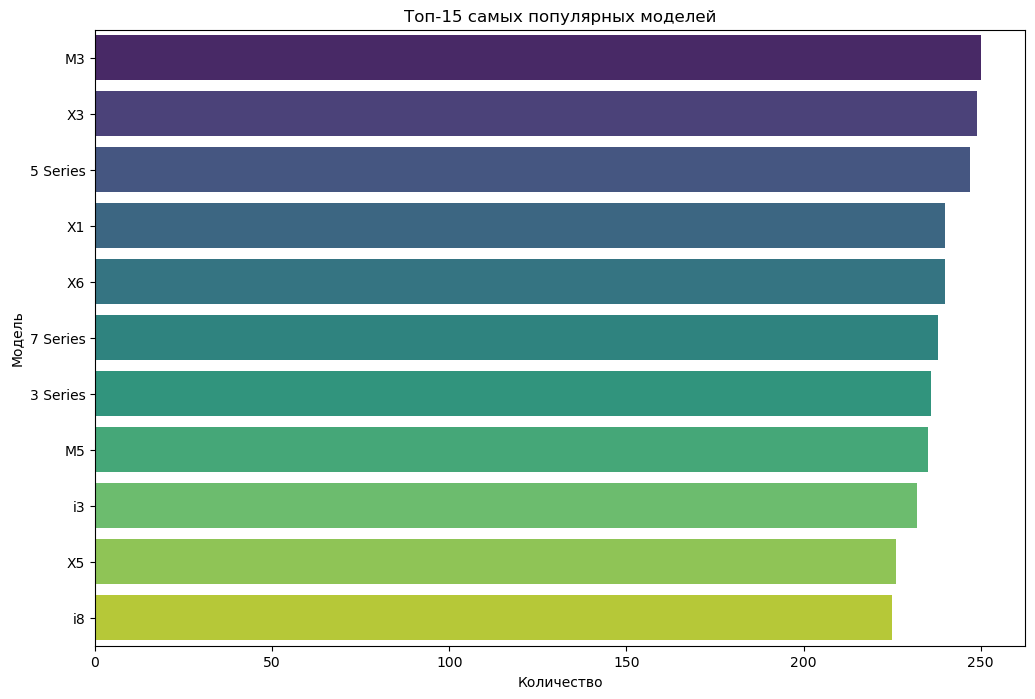

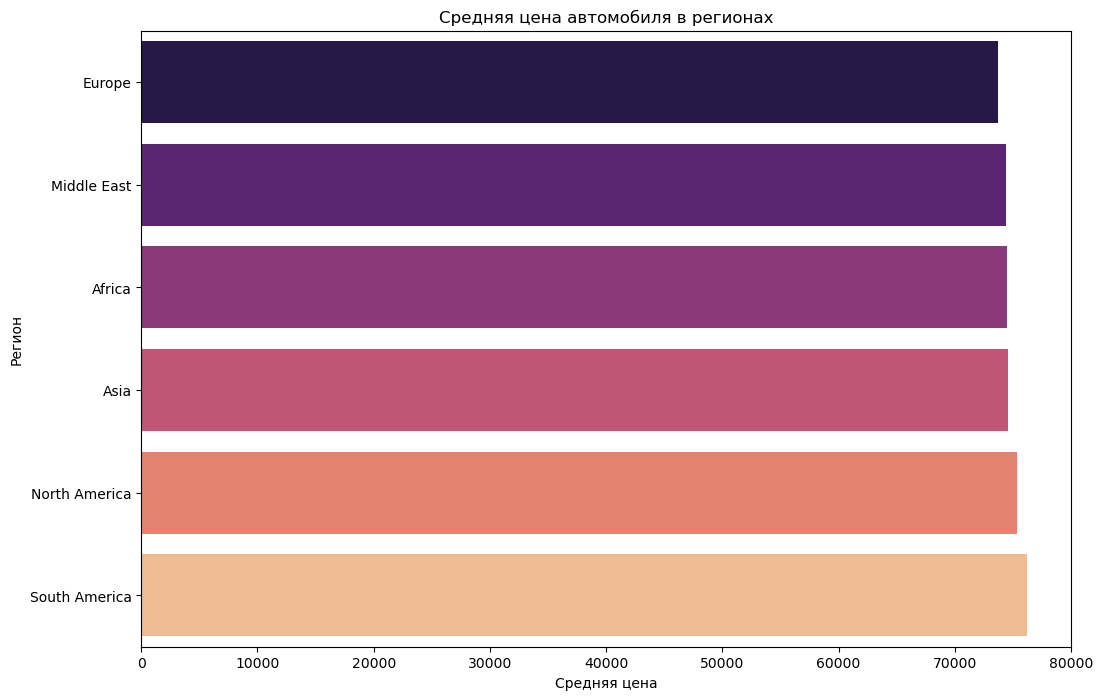

In [68]:
 #Топ-15 моделей по количеству в базе
top_models = df_4['Модель'].value_counts().nlargest(15).index

plt.figure(figsize=(12, 8))
sns.countplot(y='Модель', data=df_4[df_4['Модель'].isin(top_models)], 
              order=top_models, palette='viridis')
plt.title('Топ-15 самых популярных моделей')
plt.xlabel('Количество')
plt.show()

# Средняя цена по регионам
top_regions = df_4['Регион'].value_counts().nlargest(6).index
region_price = df_4[df_4['Регион'].isin(top_regions)].groupby('Регион')['Цена'].mean().sort_values()

plt.figure(figsize=(12, 8))
sns.barplot(x=region_price.values, y=region_price.index, palette='magma')
plt.title('Средняя цена автомобиля в регионах')
plt.xlabel('Средняя цена')
plt.show()

Выводы: 
1. По графику «Средняя цена автомобиля в регионах»
Вывод: Полное отсутствие региональной специфики в цене.
Наблюдение: Разброс цен между регионами ничтожен. Самый «дорогой» регион (South America) и самый «дешевый» (Europe) отличаются буквально на 2-3 тысячи у.е. при средней цене около 74 000.
Аномалия: В реальном мире цены на автомобили (особенно BMW) кардинально отличаются в зависимости от страны из-за пошлин, налогов и логистики (разница между США и Европой может достигать 30-50%). Здесь же график выглядит как "кирпич" — абсолютно ровный.
Итог: Регион не влияет на цену в этом датасете.
2. По графику «Топ-15 самых популярных моделей»
Вывод: Неестественно равномерный спрос.
Наблюдение: Количество проданных машин разных моделей почти одинаковое. Лидер (BMW M3, ~250 шт.) опережает аутсайдера списка (BMW i8, ~225 шт.) всего на ~25 машин.
Аномалия: В реальности существует огромный разрыв между массовыми моделями (3 Series, X3) и нишевыми/спортивными (M5, i8). Обычно массовых продают в разы больше. Здесь же редкий суперкар i8 продается почти в тех же объемах, что и кроссовер X5.
Итог: Выборка идеально сбалансирована по классам. Это хорошо для обучения нейросетей (модель не будет перекашиваться), но это не отражает реальную рыночную статистику.

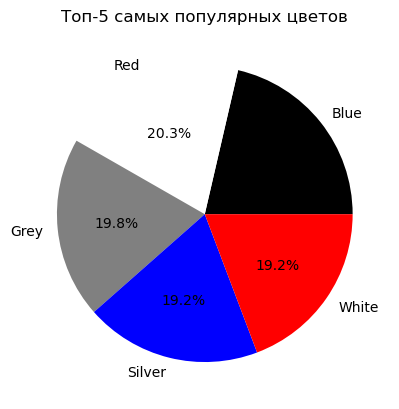

In [69]:
# 2.1 Распределение цветов (топ-5)
top_colors = df_4['Цвет'].value_counts().head(5)
plt.pie(top_colors.values, labels=top_colors.index, autopct='%1.1f%%', colors=['black', 'white', 'gray', 'blue', 'red'])
plt.title('Топ-5 самых популярных цветов')
plt.show()

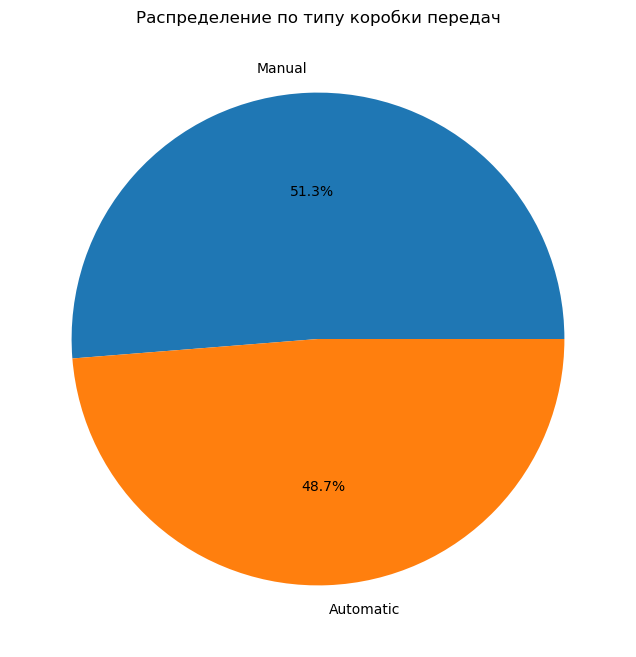

In [70]:
# 2.2 Распределение по коробке передач
transmission_counts = df_4['Коробка передач'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(transmission_counts.values, labels=transmission_counts.index, autopct='%1.1f%%')
plt.title('Распределение по типу коробки передач')
plt.show()

1. По графику «Распределение по типу коробки передач»
Вывод: Абсолютная симметрия (50/50).
Цифры: Механика (51.3%) и Автомат (48.7%) делят рынок практически поровну.
Почему это странно: В современном мире, особенно в сегменте BMW (премиум), доля механических коробок стремительно падает и составляет обычно менее 10-20% (а для моделей типа X5, X6 или 7 Series, которые были в моем топе, механика вообще практически не выпускается).
2. По графику «Топ-5 самых популярных цветов»
Вывод: Искусственное выравнивание долей (по ~20%).
Цифры: Все 5 цветов (Red, Grey, Silver, White, Blue) занимают почти одинаковые доли — около 19-21%. Если сложить их, получится идеальный "пирог" из 5 равных кусков.
Почему это странно: В реальности существует "диктатура монохрома": белый, черный, серый и серебристый занимают около 80% мирового рынка. Красный и синий — это нишевые цвета (обычно 5-8%). Здесь же красный так же популярен, как серый.
Итог: Распределение цветов не подчиняется рыночным законам, а следует математической логике "всем поровну".

## Итоговый вывод: 

На основе проведенного разведочного анализа данных (EDA), включающего изучение корреляций, распределений и визуализацию категориальных переменных, можно сделать однозначный вывод: данный набор данных является полностью синтетическим (искусственно сгенерированным).
Плюс: На таких данных идеально учиться строить графики (они всегда получаются красивыми и ровными).
Минус: Анализировать их с целью поиска бизнес-инсайтов (трендов, зависимостей цены от пробега и т.д.) бессмысленно — закономерностей там просто не заложено.
Основные доказательства искусственности:
- Отсутствие фундаментальных зависимостей (Корреляция ~0):
Матрица корреляций показала коэффициенты близкие к нулю (< 0.03) для всех пар переменных.
Отсутствует связь «Цена — Пробег» и «Цена — Год выпуска». В реальности это сильнейшие зависимости (машина дешевеет со временем и износом), здесь же они отсутствуют, что превращает данные в «белый шум».

- Идеализированные математические распределения:
Числовые переменные (Цена, Пробег, Продажи): Имеют идеальное нормальное распределение (Гаусса) с классическим «колоколом», симметричными усами и одинаковым процентом выбросов с обеих сторон. В реальности такие данные всегда имеют скос (например, длинный хвост в сторону высоких цен).
Категориальные переменные (Цвет, Регион, Модель): Имеют идеально равномерное распределение. Доли цветов равны (~20%), доли продаж по регионам почти идентичны. Рыночные перекосы (популярность черного/белого цветов или кроссоверов) отсутствуют.
Бинарные переменные: Нереалистичное распределение 50/50 между механикой и автоматом для премиум-сегмента.
Нарушение бизнес-логики и здравого смысла:
Редкие спорткары (BMW i8) продаются в тех же объемах, что и массовые кроссоверы (BMW X5).
Тип двигателя (электро, дизель, бензин) никак не влияет на среднюю цену, что невозможно в реальной экономике.
Региональные различия в ценообразовании полностью отсутствуют.
Можно ли использовать датасет дальше ? Я отвечу НЕТ.
- Для бизнеса и аналитики: Датасет непригоден для поиска инсайтов, прогнозирования цен, построения маркетинговых стратегий или изучения спроса. Любые выводы, сделанные на его основе (например, "в Африке нужно продавать больше красных машин"), будут ложными.

- Для обучения и разработки: Датасет идеально подходит для:
Отработки навыков написания кода. На этом всё.
